In [1]:
import matplotlib.pyplot as plt
import numpy
import pandas
import sys
from sklearn import tree
# Set some options for printing all the columns
numpy.set_printoptions(precision = 10, threshold = sys.maxsize)
numpy.set_printoptions(linewidth = numpy.inf)
pandas.set_option('display.max_columns', None)
pandas.set_option('display.expand_frame_repr', False)
pandas.set_option('max_colwidth', None)
pandas.options.display.float_format = '{:,.10f}'.format

In [3]:
inputData = pandas.read_csv(r'data\\cars.csv')
inputData

,Make,Model,Type,Origin,DriveTrain,MSRP,Invoice,EngineSize,Cylinders,Horsepower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,AWD,36945,33337,3.5000000000,6.0000000000,265,17,23,4451,106,189
1,Acura,RSX Type S 2dr,Sedan,Asia,FWD,23820,21761,2.0000000000,4.0000000000,200,24,31,2778,101,172
2,Acura,TSX 4dr,Sedan,Asia,FWD,26990,24647,2.4000000000,4.0000000000,200,22,29,3230,105,183
3,Acura,TL 4dr,Sedan,Asia,FWD,33195,30299,3.2000000000,6.0000000000,270,20,28,3575,108,186
4,Acura,3.5 RL 4dr,Sedan,Asia,FWD,43755,39014,3.5000000000,6.0000000000,225,18,24,3880,115,197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,Volvo,C70 LPT convertible 2dr,Sedan,Europe,FWD,40565,38203,2.4000000000,5.0000000000,197,21,28,3450,105,186
424,Volvo,C70 HPT convertible 2dr,Sedan,Europe,FWD,42565,40083,2.3000000000,5.0000000000,242,20,26,3450,105,186
425,Volvo,S80 T6 4dr,Sedan,Europe,FWD,45210,42573,2.9000000000,6.0000000000,268,19,26,3653,110,190
426,Volvo,V40,Wagon,Europe,FWD,26135,24641,1.9000000000,4.0000000000,170,22,29,2822,101,180


In [16]:
sedan = inputData[inputData['Type'] == 'Sedan']
input_y = sedan['MSRP']
input_X = sedan[['EngineSize', 'Horsepower', 'Weight', 'Length', 'Wheelbase']]

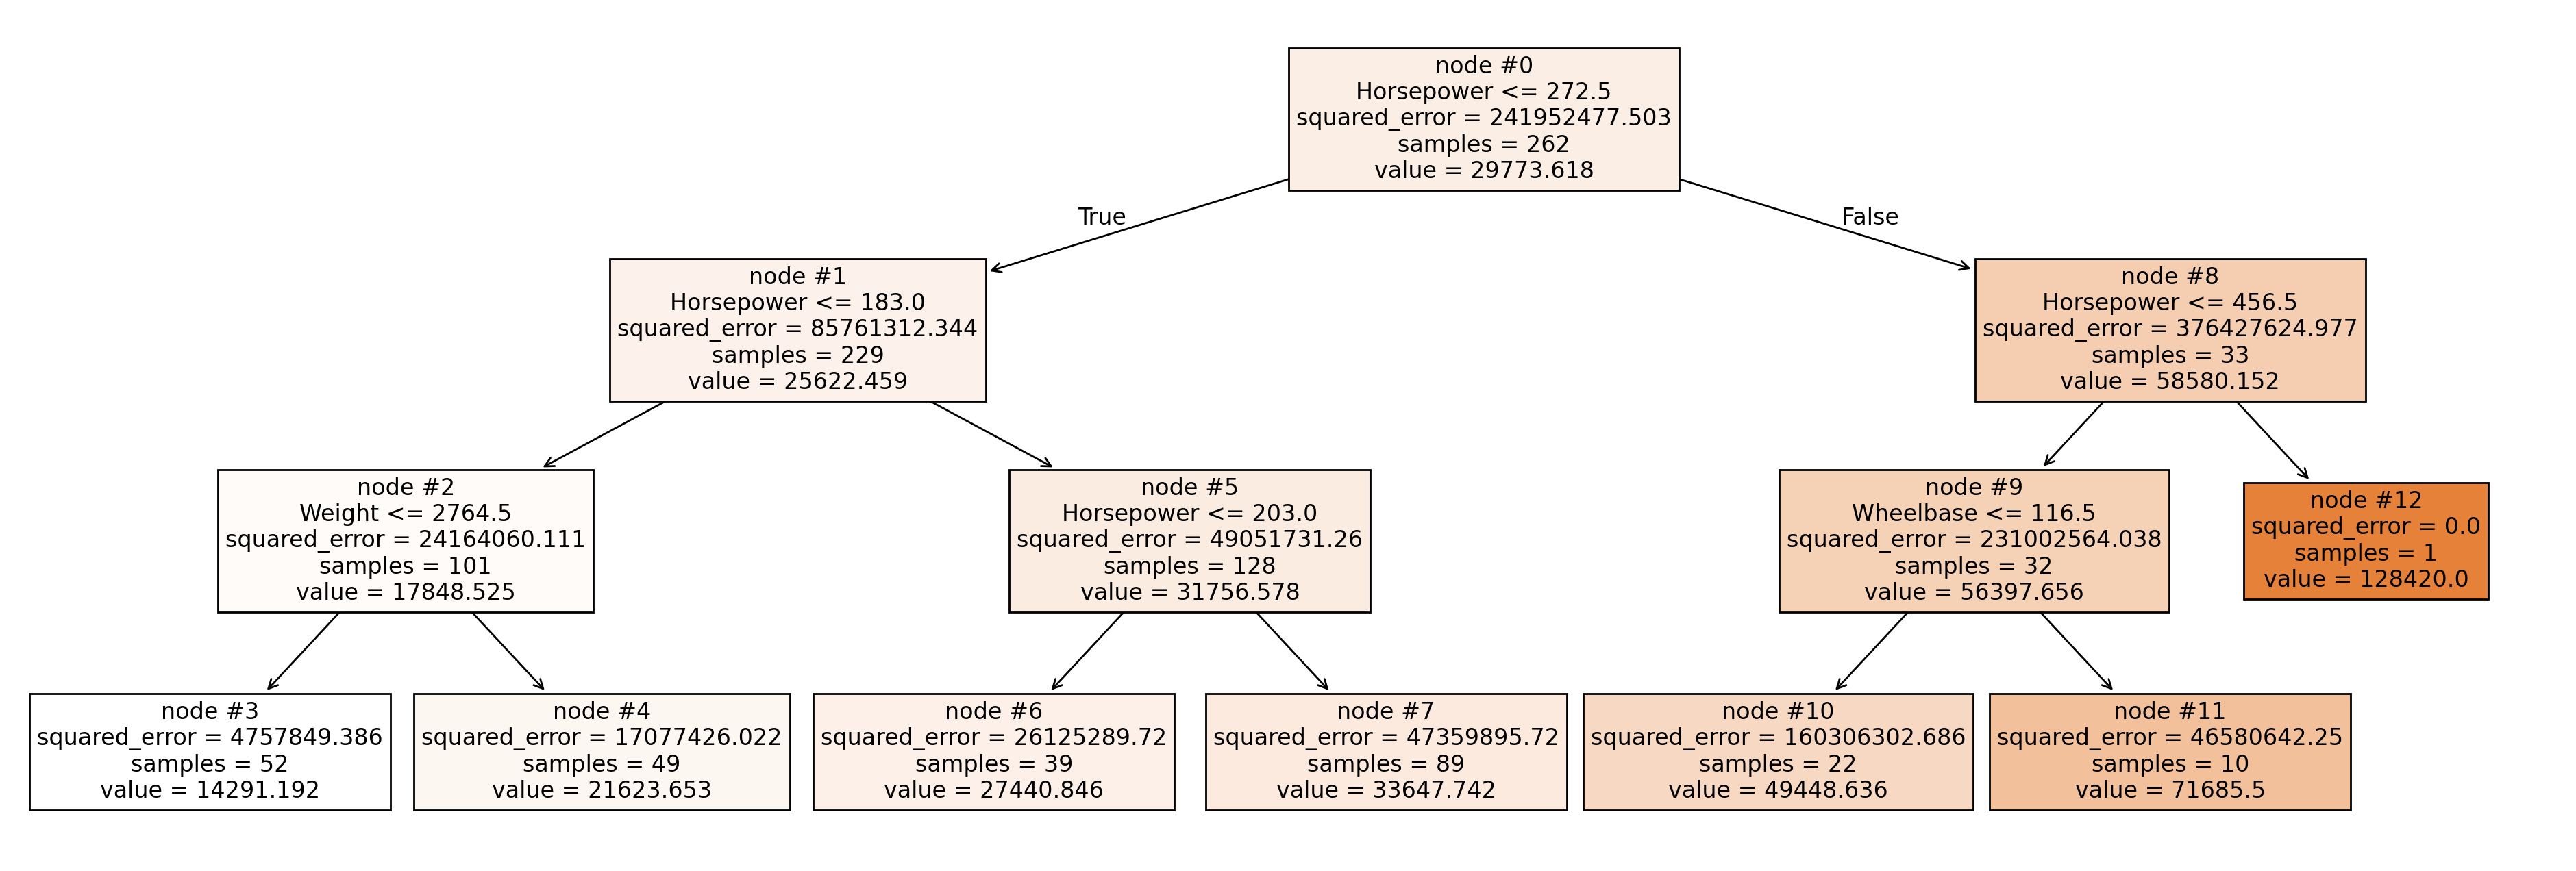

In [17]:

regTree = tree.DecisionTreeRegressor(criterion = 'squared_error',
                                     max_depth = 3, random_state = 20231225)
model = regTree.fit(input_X, input_y)
fig, ax = plt.subplots(1, 1, figsize = (24,8), dpi = 200)
tree.plot_tree(model, feature_names = input_X.columns, label = 'all',
               filled = True, impurity = True, node_ids = True,
               rounded = False, precision = 3, ax = ax, fontsize = 12)
plt.show()

,horizontal,vertical,feature
0,-1.2000000000,0.7630000000,1
1,-1.2000000000,0.7630000000,1
2,-1.1500000000,0.5430000000,1
3,-1.1500000000,0.9830000000,1
4,-1.1000000000,0.4630000000,1
...,...,...,...
124,0.2000000000,-1.5370000000,4
125,0.4000000000,-1.5870000000,4
126,0.6000000000,-1.6370000000,4
127,0.8000000000,-1.6870000000,4


### Face

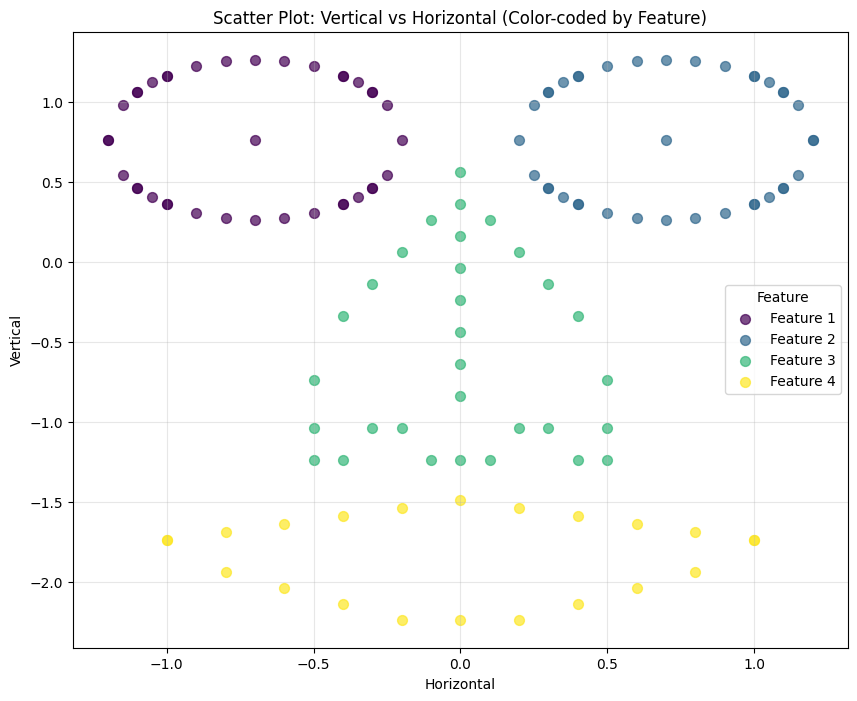

In [31]:
face = pandas.read_csv(r'data\Face.csv')
face
plt.figure(figsize=(10, 8))

# Get unique feature values and create a color map
features = face['feature'].unique()
colors = plt.cm.viridis(numpy.linspace(0, 1, len(features)))

# Plot each feature separately with its own color and label
for i, feature_val in enumerate(sorted(features)):
    mask = face['feature'] == feature_val
    plt.scatter(face.loc[mask, 'horizontal'], face.loc[mask, 'vertical'], 
                c=[colors[i]], s=50, alpha=0.7, label=f'Feature {feature_val}')

plt.xlabel('Horizontal')
plt.ylabel('Vertical')
plt.title('Scatter Plot: Vertical vs Horizontal (Color-coded by Feature)')
plt.legend(title='Feature', loc='best')
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
x = face[['horizontal', 'vertical']]
y = face['feature']
y.unique()

array([1, 2, 3, 4])

Accuracy of Decision Tree classifier on training set: 1.000000


[Text(0.4444444444444444, 0.9, 'node #0\nvertical <= 0.268\ngini = 0.74\nsamples = 129\nvalue = [38, 38, 31, 22]\nclass = Feature 1'),
 Text(0.2222222222222222, 0.7, 'node #1\nvertical <= -1.362\ngini = 0.528\nsamples = 53\nvalue = [1, 1, 29, 22]\nclass = Feature 3'),
 Text(0.3333333333333333, 0.8, 'True  '),
 Text(0.1111111111111111, 0.5, 'node #2\ngini = 0.0\nsamples = 22\nvalue = [0, 0, 0, 22]\nclass = Feature 4'),
 Text(0.3333333333333333, 0.5, 'node #3\nhorizontal <= -0.6\ngini = 0.123\nsamples = 31\nvalue = [1, 1, 29, 0]\nclass = Feature 3'),
 Text(0.2222222222222222, 0.3, 'node #4\ngini = 0.0\nsamples = 1\nvalue = [1, 0, 0, 0]\nclass = Feature 1'),
 Text(0.4444444444444444, 0.3, 'node #5\nhorizontal <= 0.6\ngini = 0.064\nsamples = 30\nvalue = [0, 1, 29, 0]\nclass = Feature 3'),
 Text(0.3333333333333333, 0.1, 'node #6\ngini = 0.0\nsamples = 29\nvalue = [0, 0, 29, 0]\nclass = Feature 3'),
 Text(0.5555555555555556, 0.1, 'node #7\ngini = 0.0\nsamples = 1\nvalue = [0, 1, 0, 0]\nclass

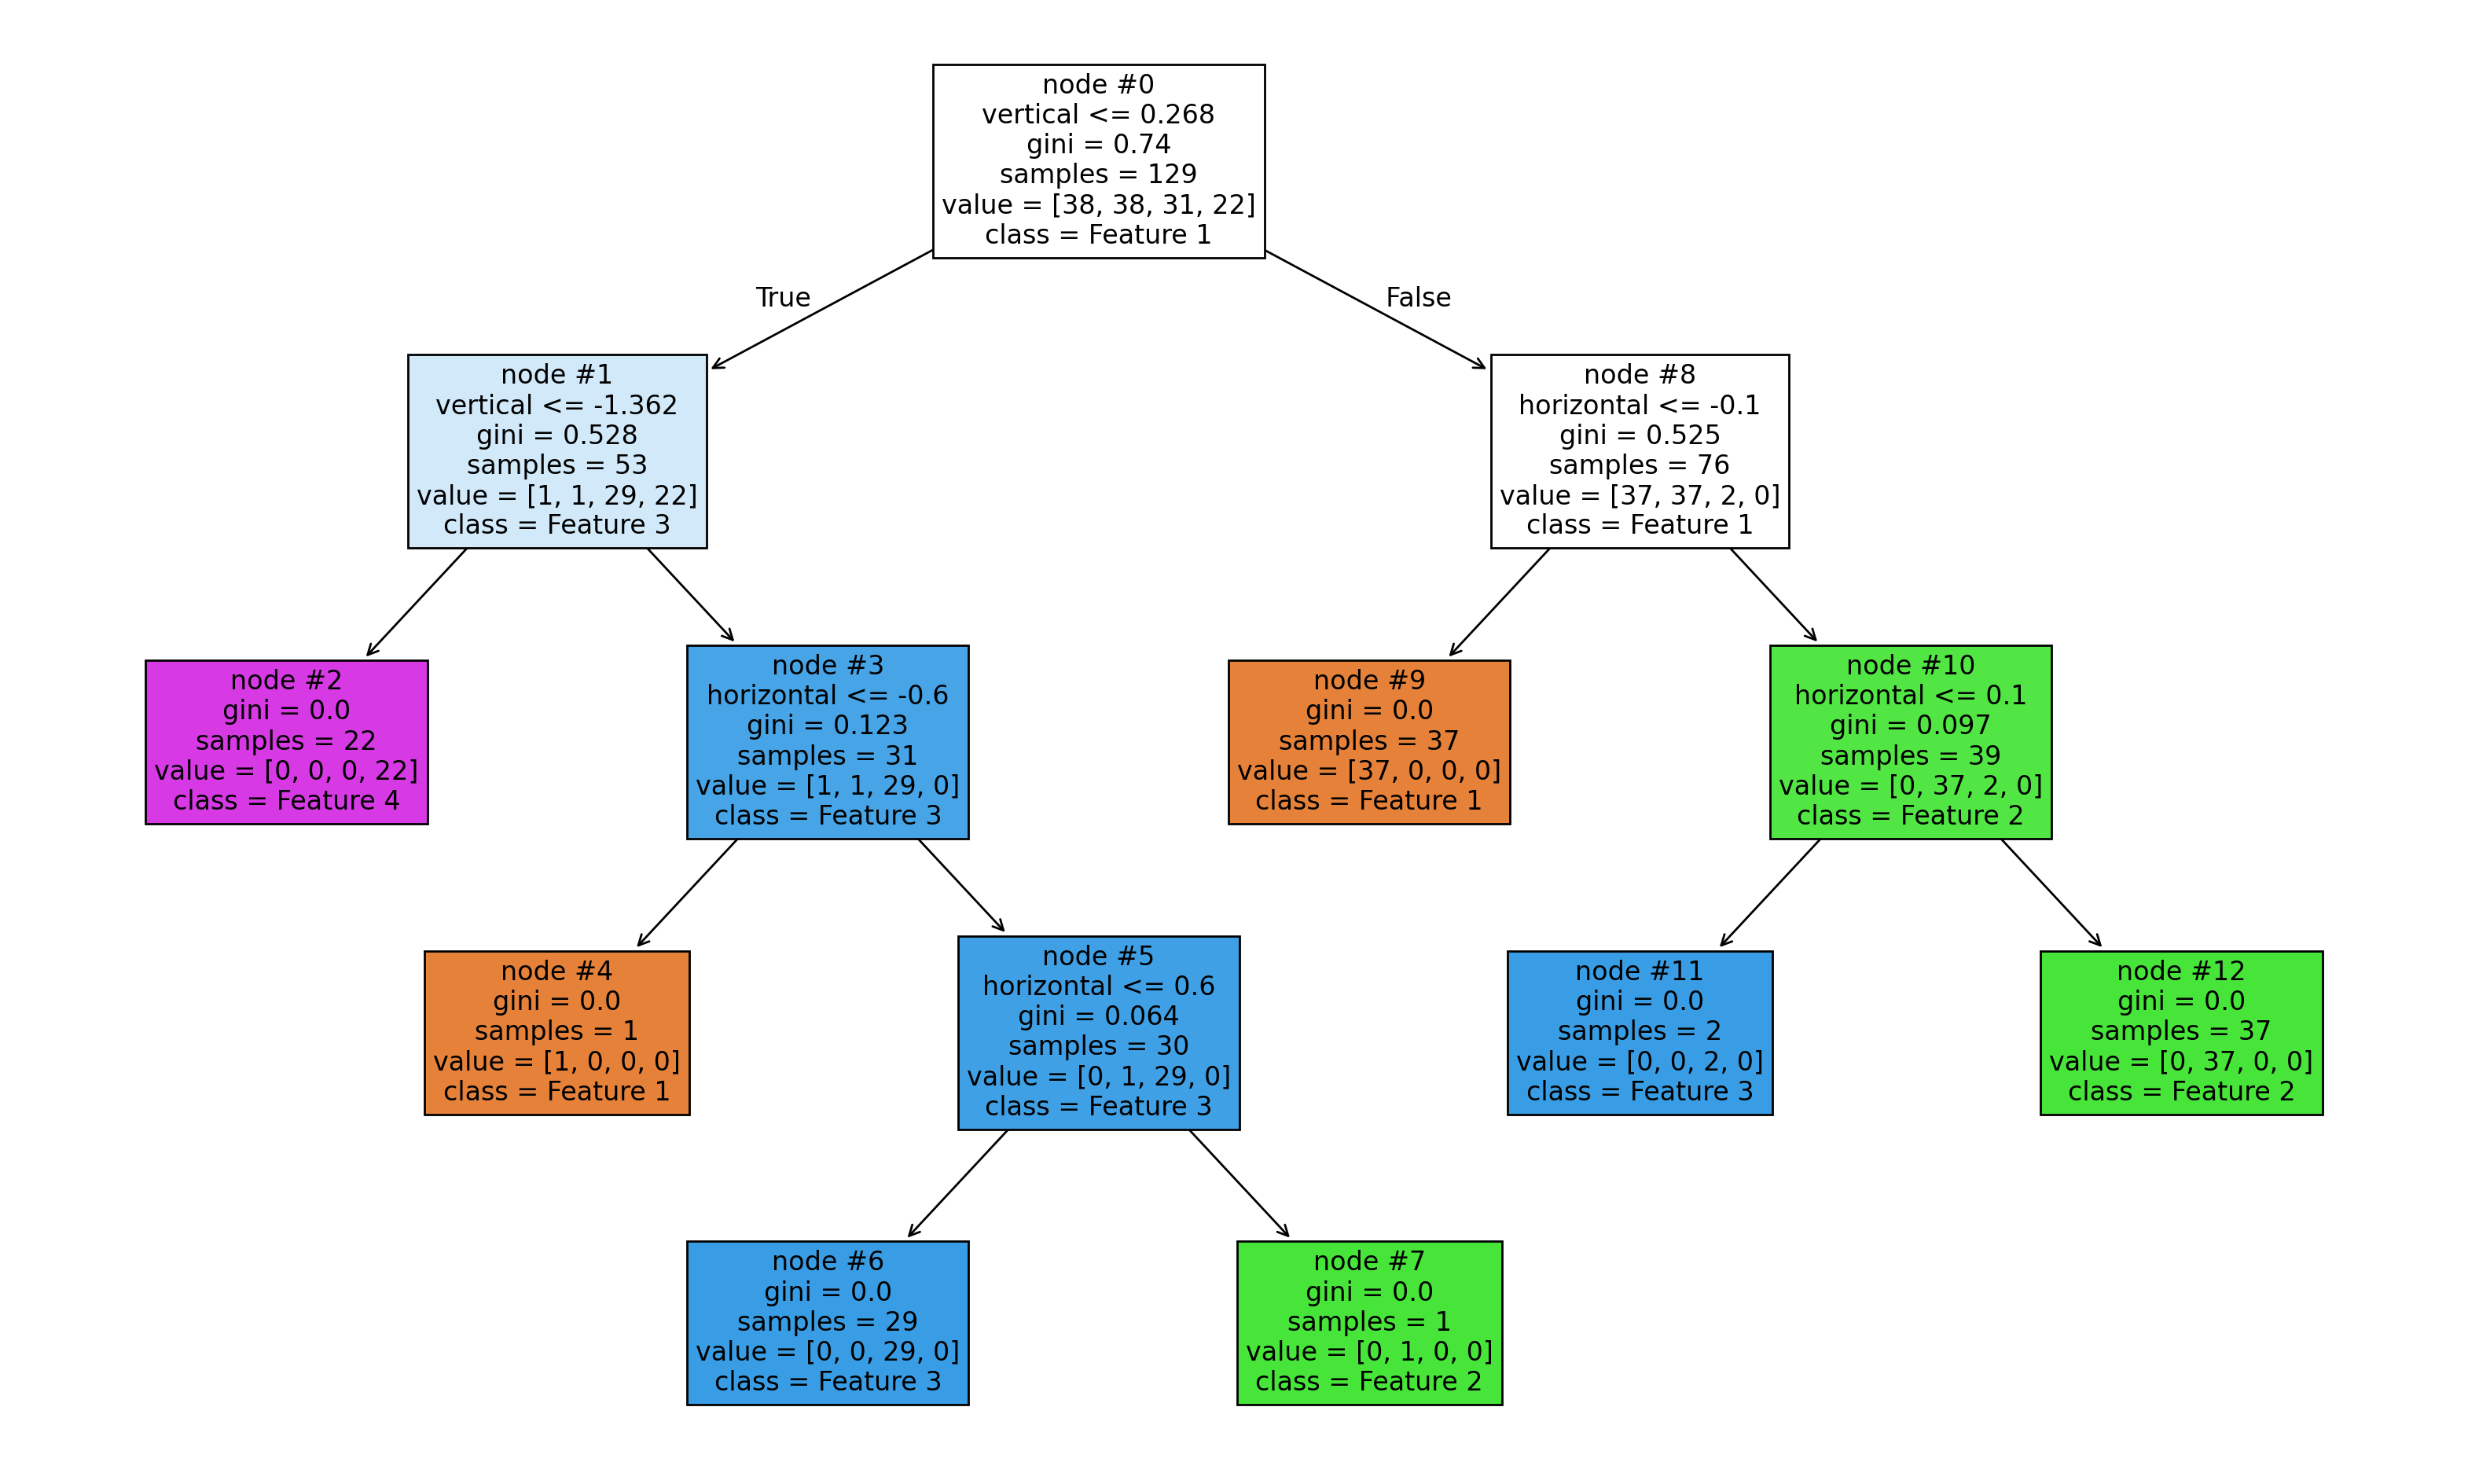

In [28]:
# Load the TREE library from SKLEARN
from sklearn import tree
classTree = tree.DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=60616)

face_dt = classTree.fit(x, y)
dt_accuracy = classTree.score(x, y)
print('Accuracy of Decision Tree classifier on training set: {:.6f}' .format(dt_accuracy))

fig, ax = plt.subplots(1, 1, figsize = (20,12), dpi = 200)
tree.plot_tree(face_dt, feature_names = ['horizontal', 'vertical']
                , class_names = ['Feature 1', 'Feature 2', 'Feature 3', 'Feature 4'],
                label='all', filled=True, impurity=True, node_ids=True, proportion=False,
                rounded=False, precision=3, ax=ax, fontsize=12) 


In [29]:
# Count leaf nodes for each feature class (Gini-based tree)
n_nodes = face_dt.tree_.node_count
children_left = face_dt.tree_.children_left
children_right = face_dt.tree_.children_right
value = face_dt.tree_.value

# Find leaf nodes and their predicted classes
leaf_nodes_by_class = {1: [], 2: [], 3: [], 4: []}

for i in range(n_nodes):
    # A node is a leaf if both children are -1
    if children_left[i] == children_right[i]:  # Leaf node
        # Get the predicted class for this leaf
        predicted_class = numpy.argmax(value[i]) + 1  # +1 because classes are 1,2,3,4
        leaf_nodes_by_class[predicted_class].append(i)

# Count and display results
print("Number of leaf nodes (decision rules) for each feature (Gini-based tree):\n")
for feature_num in sorted(leaf_nodes_by_class.keys()):
    count = len(leaf_nodes_by_class[feature_num])
    print(f"Feature {feature_num}: {count} leaf node(s)")

# Find the feature with minimum leaf nodes
min_feature = min(leaf_nodes_by_class.keys(), key=lambda k: len(leaf_nodes_by_class[k]))
min_count = len(leaf_nodes_by_class[min_feature])
print(f"\n{'='*60}")
print(f"ANSWER: Feature {min_feature} requires the least number of")
print(f"decision rules with {min_count} leaf node(s)")
print(f"{'='*60}")

Number of leaf nodes (decision rules) for each feature (Gini-based tree):

Feature 1: 2 leaf node(s)
Feature 2: 2 leaf node(s)
Feature 3: 2 leaf node(s)
Feature 4: 1 leaf node(s)

ANSWER: Feature 4 requires the least number of
decision rules with 1 leaf node(s)


Accuracy of Decision Tree classifier on training set: 1.000000


[Text(0.4444444444444444, 0.875, 'node #0\nvertical <= 0.213\nentropy = 1.968\nsamples = 129\nvalue = [38, 38, 31, 22]\nclass = Feature 1'),
 Text(0.2222222222222222, 0.625, 'node #1\nvertical <= -1.362\nentropy = 0.992\nsamples = 49\nvalue = [0.0, 0.0, 27.0, 22.0]\nclass = Feature 3'),
 Text(0.3333333333333333, 0.75, 'True  '),
 Text(0.1111111111111111, 0.375, 'node #2\nentropy = 0.0\nsamples = 22\nvalue = [0, 0, 0, 22]\nclass = Feature 4'),
 Text(0.3333333333333333, 0.375, 'node #3\nentropy = 0.0\nsamples = 27\nvalue = [0, 0, 27, 0]\nclass = Feature 3'),
 Text(0.6666666666666666, 0.625, 'node #4\nhorizontal <= -0.15\nentropy = 1.236\nsamples = 80\nvalue = [38, 38, 4, 0]\nclass = Feature 1'),
 Text(0.5555555555555556, 0.75, '  False'),
 Text(0.5555555555555556, 0.375, 'node #5\nentropy = 0.0\nsamples = 38\nvalue = [38, 0, 0, 0]\nclass = Feature 1'),
 Text(0.7777777777777778, 0.375, 'node #6\nhorizontal <= 0.15\nentropy = 0.454\nsamples = 42\nvalue = [0, 38, 4, 0]\nclass = Feature 2'),

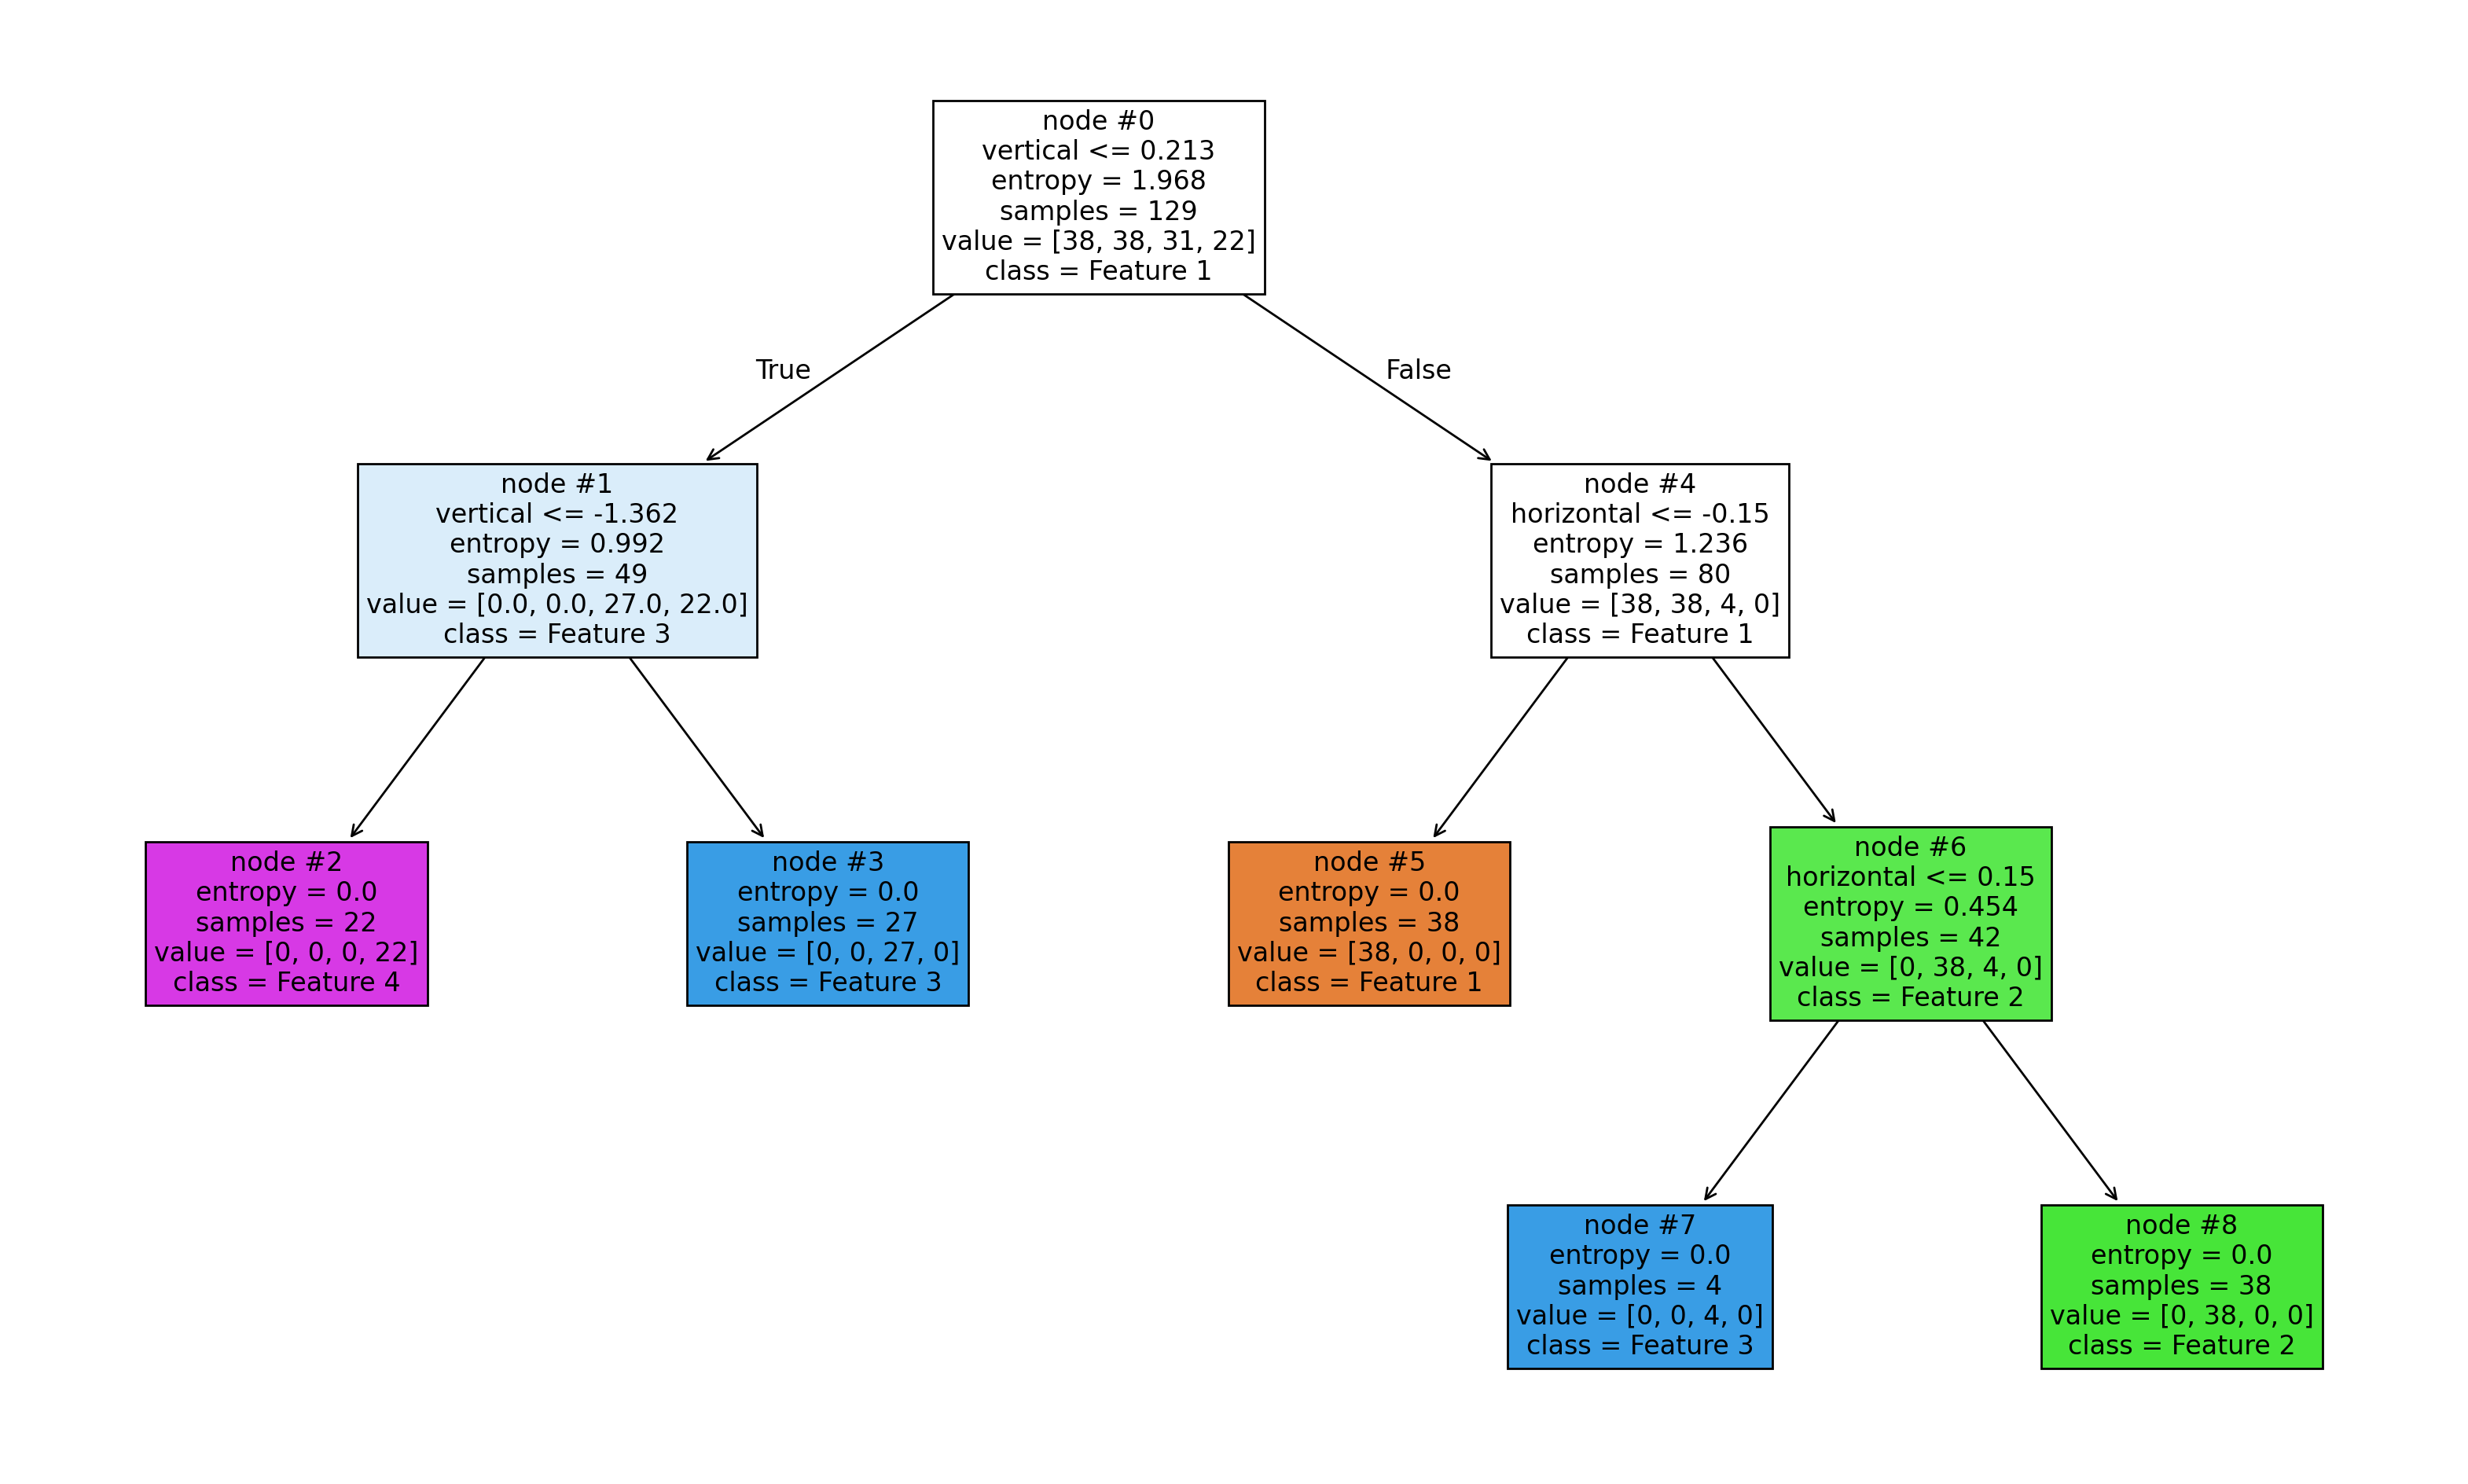

In [ ]:
# Load the TREE library from SKLEARN
from sklearn import tree
classTree = tree.DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=60616)

face_dt = classTree.fit(x, y)
dt_accuracy = classTree.score(x, y)
print('Accuracy of Decision Tree classifier on training set: {:.6f}' .format(dt_accuracy))

fig, ax = plt.subplots(1, 1, figsize = (20,12), dpi = 200)
tree.plot_tree(face_dt, feature_names = ['horizontal', 'vertical']
                , class_names = [ 'Feature 1', 'Feature 2', 'Feature 3', 'Feature 4'],
                label='all', filled=True, impurity=True, node_ids=True, proportion=False,
                rounded=False, precision=3, ax=ax, fontsize=12) 


In [33]:
# Count leaf nodes for each feature class (Entropy-based tree)
n_nodes = classTree.tree_.node_count
children_left = classTree.tree_.children_left
children_right = classTree.tree_.children_right
feature_array = classTree.tree_.feature
value = classTree.tree_.value

# Find leaf nodes and their predicted classes
leaf_nodes_by_class = {1: [], 2: [], 3: [], 4: []}

for i in range(n_nodes):
    # A node is a leaf if both children are -1
    if children_left[i] == children_right[i]:  # Leaf node
        # Get the predicted class for this leaf
        predicted_class = numpy.argmax(value[i]) + 1  # +1 because classes are 1,2,3,4
        leaf_nodes_by_class[predicted_class].append(i)

# Count and display results
print("Number of leaf nodes (decision rules) for each feature (Entropy-based tree):\n")
print("="*60)
features_with_one_rule = []
features_with_two_rules = []

for feature_num in sorted(leaf_nodes_by_class.keys()):
    count = len(leaf_nodes_by_class[feature_num])
    print(f"Feature {feature_num}: {count} leaf node(s)")
    if count == 1:
        features_with_one_rule.append(feature_num)
    elif count == 2:
        features_with_two_rules.append(feature_num)

print("="*60)
print(f"\nFeatures with ONE rule (1 leaf node): {features_with_one_rule}")
print(f"Features with TWO rules (2 leaf nodes): {features_with_two_rules}")
print("="*60)
print("\nSUMMARY:")
if len(features_with_one_rule) == 1:
    print(f"Feature {features_with_one_rule[0]} is defined by only 1 rule")
if len(features_with_two_rules) == 3:
    print(f"Features {features_with_two_rules} each require 2 rules to define")
print("="*60)

Number of leaf nodes (decision rules) for each feature (Entropy-based tree):

Feature 1: 2 leaf node(s)
Feature 2: 2 leaf node(s)
Feature 3: 2 leaf node(s)
Feature 4: 1 leaf node(s)

Features with ONE rule (1 leaf node): [4]
Features with TWO rules (2 leaf nodes): [1, 2, 3]

SUMMARY:
Feature 4 is defined by only 1 rule
Features [1, 2, 3] each require 2 rules to define


In [34]:
# Extract decision rules from the entropy-based tree
from sklearn.tree import _tree

def get_rules(tree, feature_names, class_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    
    paths = []
    
    def recurse(node, path):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            
            # Left child (<=)
            left_path = path + [f"{name} <= {threshold:.4f}"]
            recurse(tree_.children_left[node], left_path)
            
            # Right child (>)
            right_path = path + [f"{name} > {threshold:.4f}"]
            recurse(tree_.children_right[node], right_path)
        else:
            # Leaf node - get the predicted class
            predicted_class = numpy.argmax(tree_.value[node])
            class_name = class_names[predicted_class]
            paths.append((path, class_name, node))
    
    recurse(0, [])
    return paths

# Get all rules
feature_names = ['horizontal', 'vertical']
class_names = ['Feature 1', 'Feature 2', 'Feature 3', 'Feature 4']
rules = get_rules(classTree, feature_names, class_names)

# Display rules organized by predicted feature
print("\n" + "="*80)
print("DECISION RULES FROM ENTROPY-BASED CLASSIFICATION TREE")
print("="*80)

for feature_num in [1, 2, 3, 4]:
    feature_name = f'Feature {feature_num}'
    feature_rules = [r for r in rules if r[1] == feature_name]
    
    print(f"\n{feature_name} ({len(feature_rules)} rule(s)):")
    print("-" * 80)
    
    for idx, (conditions, pred_class, node_id) in enumerate(feature_rules, 1):
        print(f"\nRule {idx} (Node {node_id}):")
        if conditions:
            for condition in conditions:
                print(f"  - {condition}")
        else:
            print("  - (Root node)")
        print(f"  => Predict: {pred_class}")

print("\n" + "="*80)


DECISION RULES FROM ENTROPY-BASED CLASSIFICATION TREE

Feature 1 (2 rule(s)):
--------------------------------------------------------------------------------

Rule 1 (Node 4):
  - vertical <= 0.2680
  - vertical > -1.3620
  - horizontal <= -0.6000
  => Predict: Feature 1

Rule 2 (Node 9):
  - vertical > 0.2680
  - horizontal <= -0.1000
  => Predict: Feature 1

Feature 2 (2 rule(s)):
--------------------------------------------------------------------------------

Rule 1 (Node 7):
  - vertical <= 0.2680
  - vertical > -1.3620
  - horizontal > -0.6000
  - horizontal > 0.6000
  => Predict: Feature 2

Rule 2 (Node 12):
  - vertical > 0.2680
  - horizontal > -0.1000
  - horizontal > 0.1000
  => Predict: Feature 2

Feature 3 (2 rule(s)):
--------------------------------------------------------------------------------

Rule 1 (Node 6):
  - vertical <= 0.2680
  - vertical > -1.3620
  - horizontal > -0.6000
  - horizontal <= 0.6000
  => Predict: Feature 3

Rule 2 (Node 11):
  - vertical > 0.2